<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter4/4_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 럭키백의 확률
로지스틱 회귀

In [1]:
#생선 데이터 준비
import pandas as pd

fish = pd.read_csv('https://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [3]:
#생선 종류
print(pd.unique(fish["Species"]))

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


In [6]:
#Species 열을 타깃으로 만들고 나머지 5개 열은 입력데이터로 사용
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]
fish_target = fish['Species']

In [7]:
#k 최근접 이웃의 다중분류
#훈련 데이터와 타깃 데이터 나누기
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

In [8]:
#훈련세트와 테스트세트 표준화 전처리
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [11]:
#k 최근접 이웃 사용
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)

#스코어 확인
print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


다중분류란?

지금 타깃 데이터에 생선 7개의 종류가 존재하는데 이렇게 타깃 데이터에 2개 이상의 클래스가 포함된 문제를 다중 분류라 한다.

In [13]:
#타깃값을 그대로 사이킷런 모델에 전달하면 순서가 자동으로 알파벳 순으로 매겨진다.
print(kn.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [16]:
#예측해보기
print(kn.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']


In [21]:
#확률 출력해보기(round() 사용해서 소수점 네번째 자리까지 표기)
import numpy as np

proba = kn.predict_proba(test_scaled[:5])
print(np.round(proba, decimals = 4))

[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [33]:
distances, indexes = kn.kneighbors(test_scaled[3:4])
print(train_target.iloc[indexes[0]])

52     Roach
106    Perch
103    Perch
Name: Species, dtype: object


## 로지스틱 회귀(분류모델)
인공 신경망에서 기본이 되는 모델
a, b, c, d, e는 가중치 혹은 계수.

z는 확률로 사용하려한 0~1로 만들어야하므로 시그모이드함수(로지스틱 함수)를 사용하면 된다.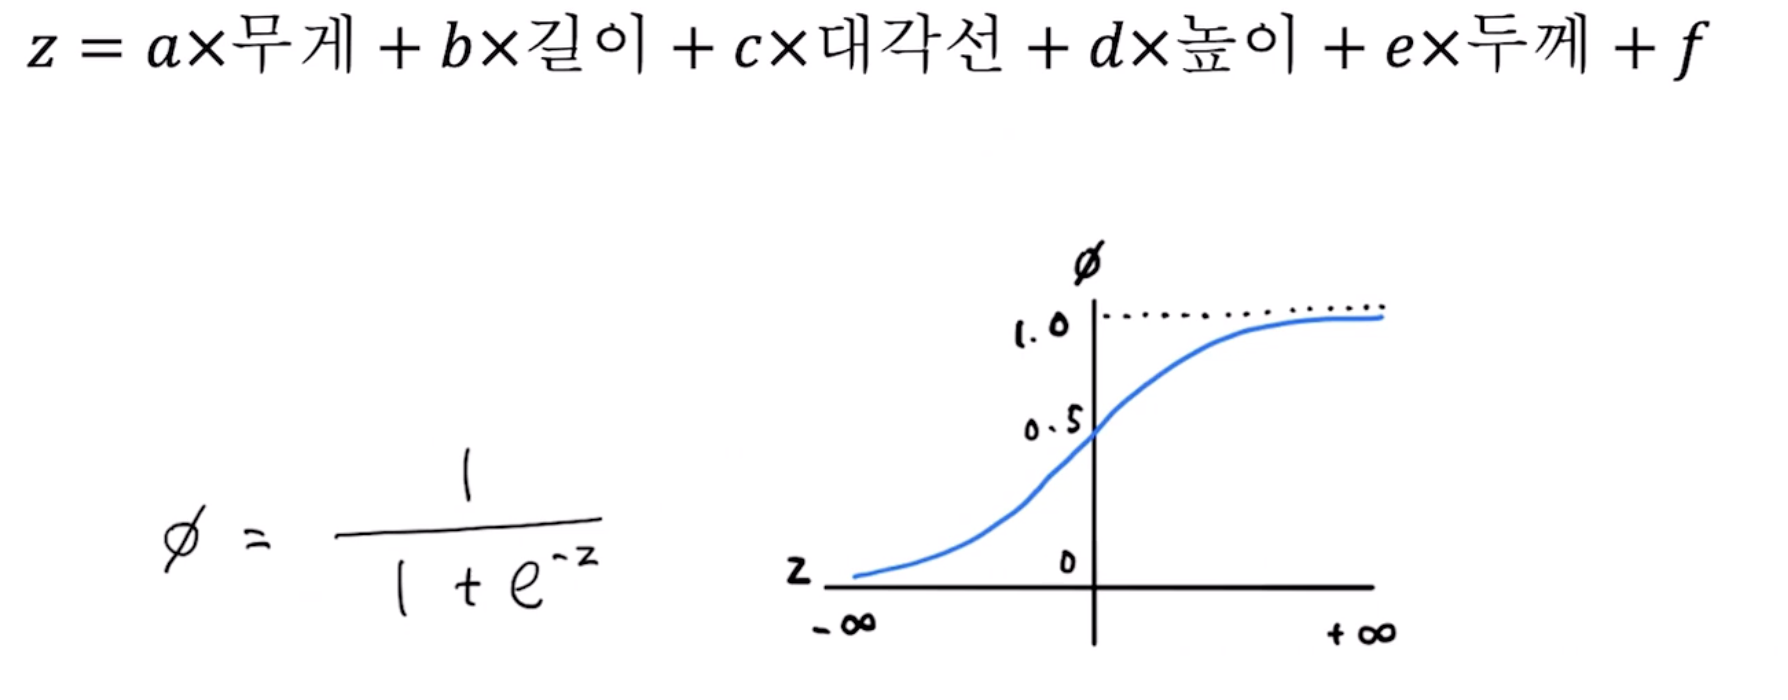

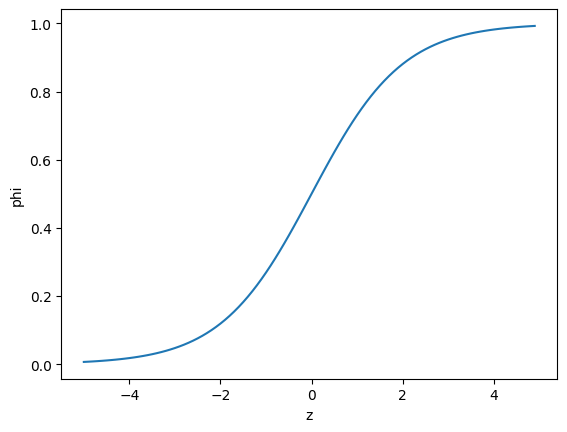

In [34]:
#시그모이드 함수 그려보기
import numpy as np
import matplotlib.pyplot as plt

z = np.arange(-5, 5, 0.1)
phi = 1 / (1 + np.exp(-z))

plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()

In [36]:
#이진분류 수행해보기(출력이 0.5보다 크면 양성클래스, 반대면 음성클래스)
char_arr = np.array(['A', 'B', 'C', 'D', 'E'])
print(char_arr[[True, False, True, False, False]])

['A' 'C']


In [40]:
#이진 분류를 이용해 도미와 빙어 행 골라내기
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

In [41]:
#로지스틱 회귀 모델 훈련
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

#훈련 모델을 사용해 train_bream_smelt 에 있는 처음 5개 예측해보기
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [43]:
#예측확률 구해보기
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [44]:
#로지스틱 회귀 계수 확인
print(lr.coef_, lr.intercept_)

[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]] [-2.16172774]


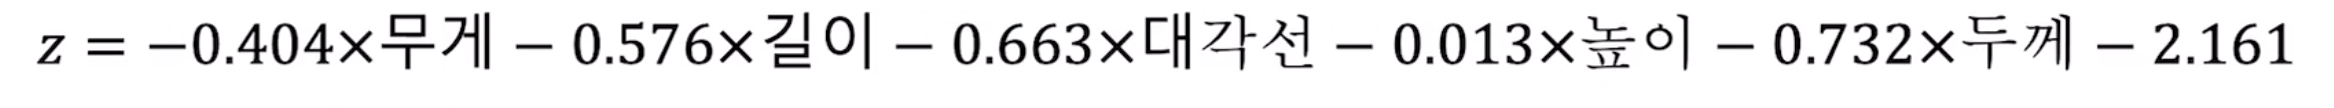

In [46]:
#z값 구하기
decisions = lr.decision_function(train_bream_smelt[:5])
print(decisions)

[-6.02991358  3.57043428 -5.26630496 -4.24382314 -6.06135688]


In [48]:
#z값을 시그모이드 함수에 통과시키기
from scipy.special import expit
print(expit(decisions))

[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


## 로지스틱 회귀(다중분류)
반복횟수를 늘리기 위해 max_iter을 1000으로 하고 릿지회귀의 alpha 매개변수같은 규제인 C를 사용. C는 작을수록 규제가 커지므로 조금 완화시키주기 위해 C를 20으로 하고 훈련시킴.

In [49]:
#다중분류 훈련시키기
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)

#스코어 확인
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [51]:
#테스트 세트 처음 5개 샘플에 대한 예측
print(lr.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [53]:
#예측 확률 출력
proba = lr.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [55]:
#다중분류일 경우 선형 방정식의 모습?
print(lr.coef_.shape, lr.intercept_.shape)

(7, 5) (7,)


소프트맥스는 시그모이드 함수와 달리 여러개의 선형 방정식의 출력값을 0~1 사이의 확률로 압축하고 전체 합이 1이 되도록 만듦.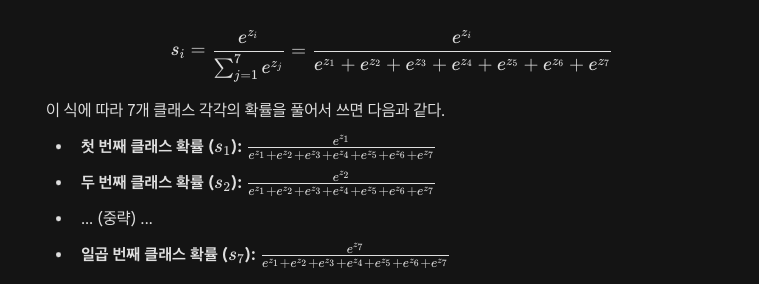

In [56]:
#z값 구하기
decision = lr.decision_function(test_scaled[:5])
print(np.round(decision, decimals=2))

[[ -6.51   1.04   5.17  -2.76   3.34   0.35  -0.63]
 [-10.88   1.94   4.78  -2.42   2.99   7.84  -4.25]
 [ -4.34  -6.24   3.17   6.48   2.36   2.43  -3.87]
 [ -0.69   0.45   2.64  -1.21   3.26  -5.7    1.26]
 [ -6.4   -1.99   5.82  -0.13   3.5   -0.09  -0.7 ]]


In [57]:
#소프트맥스 함수(axis= 는 소프트맥스를 계산할 축 지정. 1로 지정하면 각 행, 즉 각 샘플에 대해 소프트맥스를 계산. 지정하지 않으면 배열 전체에 대해 소프트맥스를 계산)
from scipy.special import softmax
proba = softmax(decision, axis = 1)
print(np.round(proba, decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


k최근접 이웃 모델이 확률을 출력할 수 있지만 항상 정해진 확률만을 출력함. 따라서 좀 더 그럴싸한 확률을 표시하기 위해 로지스틱 회귀를 사용하였고 선형 방정식을 사용.

이진분류에서는 하나의 선형 방정식을 훈련해서 출력값을 시그모이드 함수에 통과시켜 0~1사이의 값을 만들고 이 값이 양성 클래스에 대한 확률. 음성 클래스의 확류은 1에서 양성 클래스의 확류를 뺴면 됨.

다중분류에서는 클래스 개수만큼 방정식 훈련. 그 출력값을 소프트맥스 함수를 통과시켜 전체 클래스에 대한 합이 항상 1이 되도록 만듦.